# 1. 核对验证供者

CID4463在临床补充表1第19行对应Case 4463，为未治疗ER+、IDC。参考仍为CID4471和CID4535，CID4067已用于开发。

本轮先保存候选表、参考哈希和模拟配方，再拟合预测。CID4463的1138个细胞包括CAF 25个、CD8 75个、癌上皮659个和正常上皮26个。

输入由prepare_independent_validation.py生成；RCTD通过run_independent_validation.R运行。下面复用保存的RCTD预测，计算NNLS并评估。


In [1]:
from pathlib import Path
import json
import runpy
import pandas as pd
from IPython.display import display, Image, Markdown
root = Path("/Users/georicl/Documents/sc_sncell_github")
result_dir = root / "results/Wu2021_independent_validation_v1"
candidates = pd.read_csv(result_dir / "donor_candidates.csv")
display(candidates[candidates.subtype.eq("ER+")][["donor_id", "histology", "treatment_status", "CAFs", "T cells CD8+", "Cancer Epithelial", "Normal Epithelial", "role", "reason"]])
protocol = json.loads((result_dir / "protocol.json").read_text())
print("固定时间：", protocol["frozen_at_utc"])


,donor_id,histology,treatment_status,CAFs,T cells CD8+,Cancer Epithelial,Normal Epithelial,role,reason
3,CID3941,IDC,Naïve,8,126,196,0,reserve_validation,未治疗ER+，保留为后续验证；本轮未使用
5,CID3948,IDC,Naïve,15,498,261,0,reserve_validation,未治疗ER+，保留为后续验证；本轮未使用
7,CID4040,IDC,Naïve,129,528,0,0,no_cancer_control,缺少作者标注癌上皮，不能完成本轮上皮验证
9,CID4067,IDC,Naïve,135,243,2352,0,development,已用于误差检查和方案开发
10,CID4290A,NaN,NaN,280,115,4053,18,mapping_unresolved,带后缀样本未确认与临床Case ID的对应
11,CID4398,IDC,Treated,178,926,0,0,treated_or_unknown,不是已确认未治疗供者
13,CID4461,IDC,Naïve,41,11,207,0,reserve_validation,未治疗ER+，保留为后续验证；本轮未使用
14,CID4463,IDC,Naïve,25,75,659,26,independent_validation,临床精确对应，未治疗ER+，CAF/CD8/癌上皮/正常上皮均有覆盖
16,CID4471,ILC,Naïve,1292,159,212,1966,reference,已用于参考构建
24,CID4530N,NaN,NaN,368,108,1715,398,mapping_unresolved,带后缀样本未确认与临床Case ID的对应


固定时间： 2026-09-15T05:07:51.437273+00:00


# 2. 查看固定配方

237个基础混合各生成原深度和25%深度两个版本，共474个spot。每个深度含162个CAF/CD8混合、50个纯群和25个上皮比例梯度。

同一spot内不重复抽取细胞，不同spot允许复用。正常上皮梯度使用0、2、5、8、10个正常上皮，癌上皮补足10个；误差按实际RNA份额计算。

CID4463没有B细胞，跳过B细胞背景；NK只有3个，保留1细胞NK背景，跳过5细胞NK纯群。


In [2]:
design = pd.read_csv(result_dir / "simulation_design.csv", index_col=0)
display(design.groupby(["scenario", "depth_fraction"]).nUMI.agg(["size", "min", "median", "max"]))
display(pd.read_csv(result_dir / "validation_qc_summary.csv", header=[0,1], index_col=0))


size    min    median     max
scenario             depth_fraction                               
epithelial_titration 0.25              25  15961   30832.0   57632
                     1.00              25  63750  124013.0  232302
factorial            0.25             162   5171   18058.5   45727
                     1.00             162  20670   72249.0  182948
pure                 0.25              50   1200    5608.0   27783
                     1.00              50   4887   22554.0  111572

nCount_RNA                      nFeature_RNA                \
                       count   min  median    max        count   min  median   
reference_label                                                                
CAFs                      25   802  4080.0  20787           25   480  1542.0   
Cancer Epithelial        659   855  8301.0  67302          659   531  2666.0   
Cycling T-cells            5  3426  5771.0   9828            5  1507  2147.0   
Endothelial               79   433  2895.0  22308           79   291  1242.0   
Myeloid                  101   470  6264.0  26583          101   318  1751.0   
NK cells                   3   514  1870.0   2436            3   305   851.0   
NKT cells                 19   596  1389.0   3175           19   359   789.0   
Normal Epithelial         26   318  9069.0  54887           26   225  2224.5   
PVL                       31   635  1829.0   6869           31   369   844.0   
T cells CD4+             115   277  1264.0   3447          115   212   628.0   
T cells CD8+              75   311  1078.0   3505           75   221   560.0   

                        percent.mito                                 
                    max        count       min    median        max  
reference_label                                                      
CAFs               4272           25  0.853852  2.246509   9.019044  
Cancer Epithelial  7267          659  0.000000  5.704140  19.396790  
Cycling T-cells    2695            5  1.424501  2.356611   2.934035  
Endothelial        4550           79  0.356888  2.731411   9.410145  
Myeloid            4212          101  0.171233  2.216179  19.935275  
NK cells            940            3  1.361868  2.955665   4.171123  
NKT cells          1536           19  1.799856  4.201050  17.673108  
Normal Epithelial  6401           26  1.498559  4.360032  19.699833  
PVL                1915           31  1.552795  3.741447  14.269788  
T cells CD4+       1348          115  0.941423  2.979738   7.806452  
T cells CD8+       1521           75  0.647249  3.157064  12.390715

# 3. 运行评价

四套参考及各自NNLS的2000个基因均保持原样。拆分后的癌上皮权重相加后，按原13类与已知组成比较。

按混合配方、纯群和上皮梯度分别保存MAE、RMSE及平均偏移，同时保存细胞数量份额的误差。


In [3]:
evaluation = runpy.run_path(str(root / "src/sc_sncell_github/evaluate_independent_validation.py"))
evaluation["main"]()


         variant method  depth_fraction         cell_type    mae_pp
        baseline   RCTD            0.25              CAFs  1.399983
        baseline   RCTD            0.25 Cancer Epithelial 12.541824
        baseline   RCTD            0.25 Normal Epithelial 14.017706
        baseline   RCTD            0.25      T cells CD8+  1.295000
        baseline   RCTD            1.00              CAFs  1.277378
        baseline   RCTD            1.00 Cancer Epithelial 10.262011
        baseline   RCTD            1.00 Normal Epithelial 12.214626
        baseline   RCTD            1.00      T cells CD8+  1.126145
        baseline   NNLS            0.25              CAFs  4.400153
        baseline   NNLS            0.25 Cancer Epithelial 68.742311
        baseline   NNLS            0.25 Normal Epithelial 61.403409
        baseline   NNLS            0.25      T cells CD8+  2.824981
        baseline   NNLS            1.00              CAFs  4.394008
        baseline   NNLS            1.00 Cancer E

# 4. 查看预测误差和上皮梯度

误差柱图按同一类型使用相同纵轴。上皮散点图横轴为已知正常上皮RNA份额，纵轴为预测权重，直线表示两者相等。


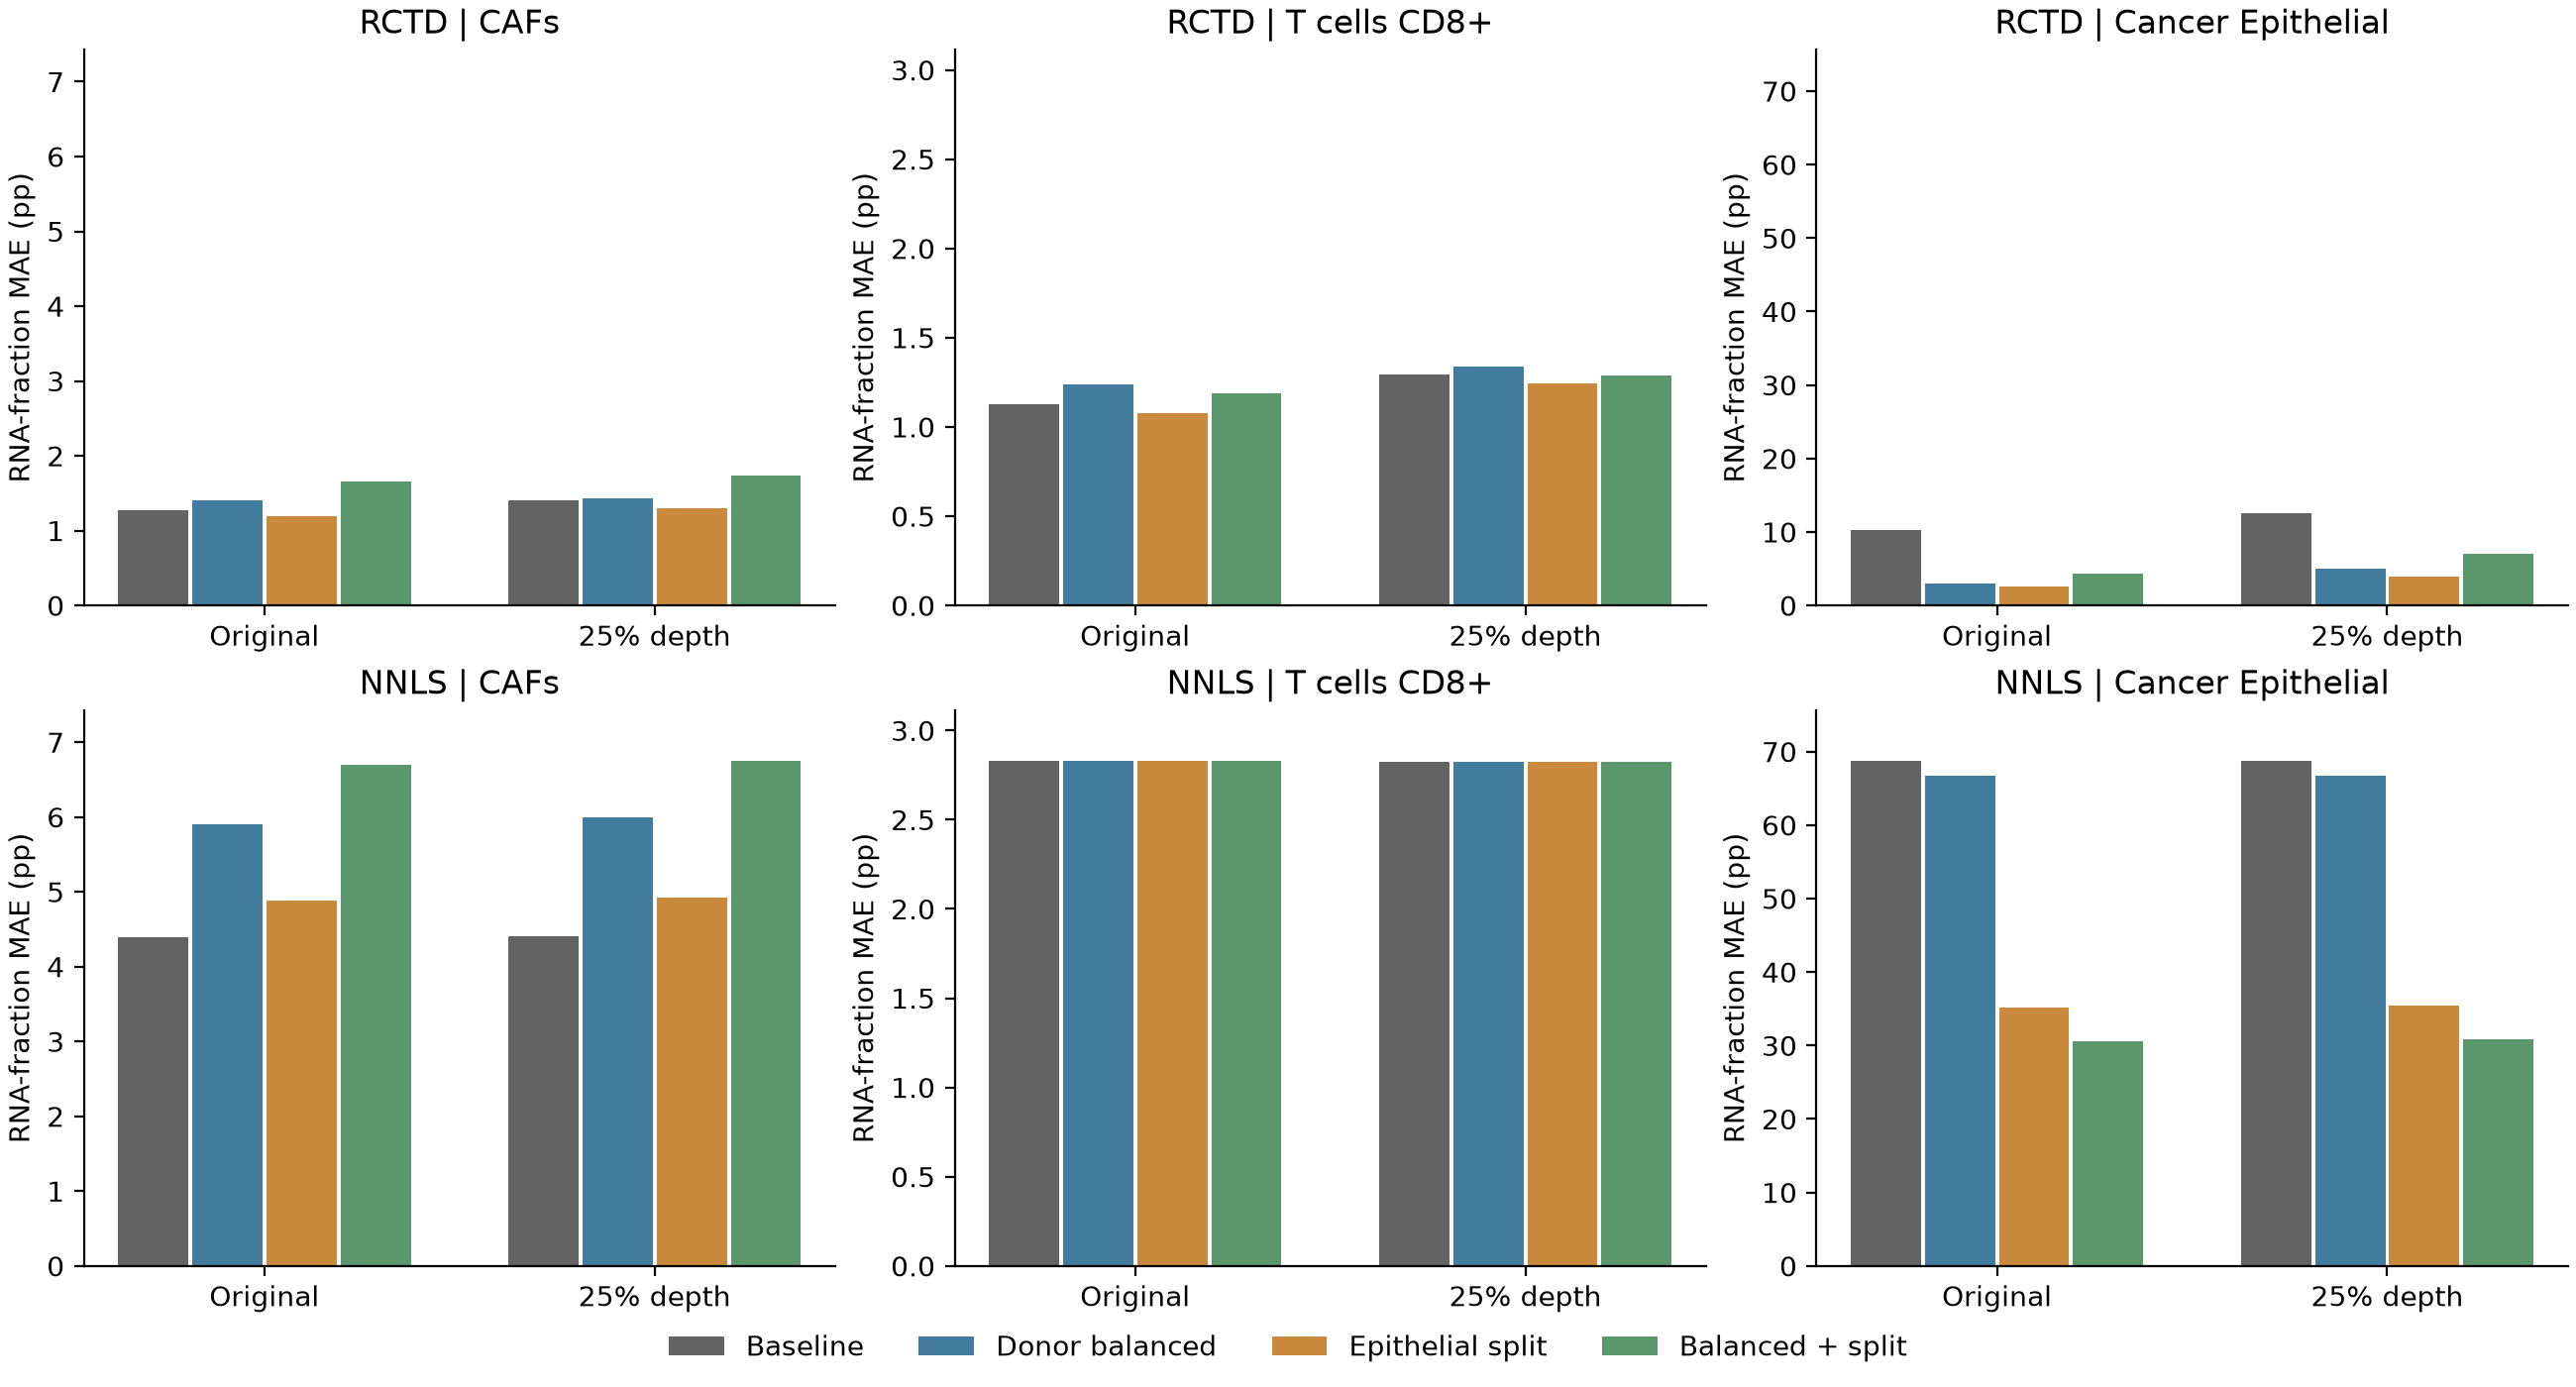

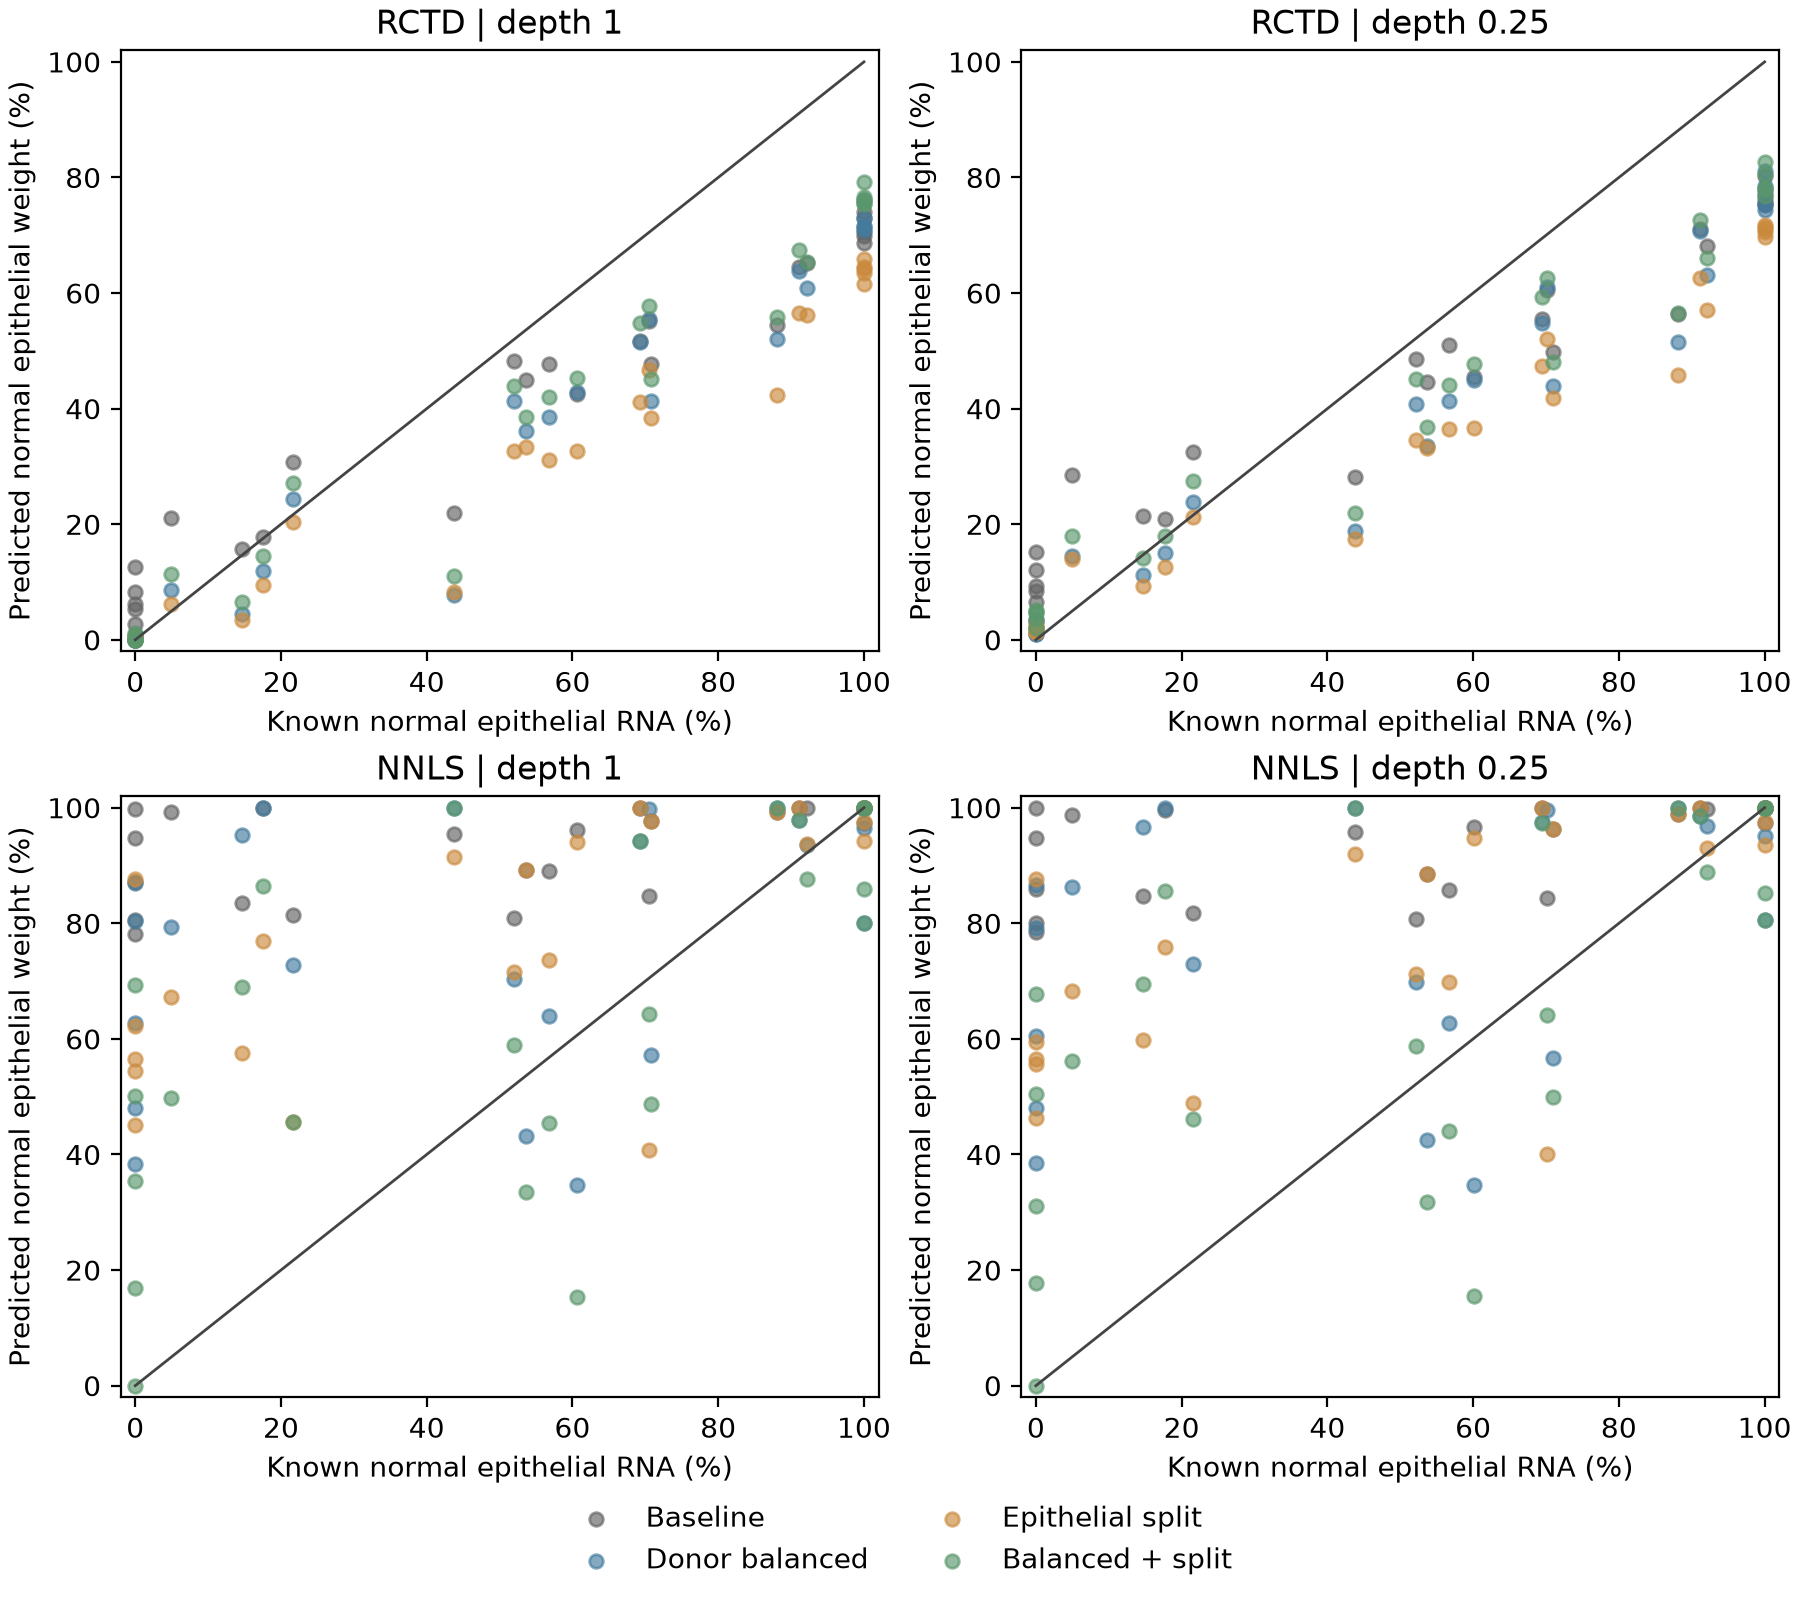

In [4]:
display(Image(filename=str(result_dir / "independent_validation.png")))
display(Image(filename=str(result_dir / "epithelial_titration.png")))


# 5. 核对计数与指标

从来源细胞重新求和，核对全部237个原深度混合；再检查抽稀计数、组成真值、参考与验证供者隔离、冻结文件哈希和指标复算。


In [5]:
runpy.run_path(str(root / "src/sc_sncell_github/validate_independent_validation.py"))
checks = json.loads((result_dir / "validation_checks.json").read_text())
print("通过检查：", sum(checks["checks"].values()), "/", len(checks["checks"]))


Checks: 67 / 67 max metric difference: 7.105427357601002e-15
通过检查： 67 / 67


# 6. 阅读本轮结果


In [6]:
display(Markdown((result_dir / "interpretation.md").read_text()))


# CID4463独立验证

## 1. 供者与固定设计

CID4463在临床补充表1第19行精确对应Case 4463，为未治疗ER+、IDC。作者病理描述包含小叶样生长区域，E-cadherin阳性；本轮沿用IDC记录。
参考固定为CID4471、CID4535，CID4067已用于开发。本轮1138个验证细胞包括CAF 25个、CD8 75个、癌上皮659个和正常上皮26个。
四套参考及NNLS特征均复用原文件，拟合前保存哈希和配方。237个基础混合生成原深度和25%深度两个版本，共474个模拟spot。
每个深度包含162个CAF/CD8混合、50个纯群对照，以及25个正常/癌上皮比例梯度。B细胞缺失，未构造B背景；NK只有3个，保留1细胞NK背景，跳过5细胞NK纯群。
Cycling T只有5个来源细胞，5次纯群使用同一组细胞。原深度计数相同，不能把5/5匹配理解为5组独立细胞的重复验证。source_mixture_diversity.csv记录各配方的不同来源细胞组合数。
## 2. 混合配方RNA份额误差

MAE单位为百分点，两个深度分别列出，不把同一供者的模拟spot当作独立患者。

| 方法 | 参考 | 深度 | CAF | CD8 | 癌上皮 | 正常上皮 | PVL |
|---|---|---|---:|---:|---:|---:|---:|
| RCTD | 原参考 | 1 | 1.28 | 1.13 | 10.26 | 12.21 | 1.39 |
| RCTD | 原参考 | 0.25 | 1.40 | 1.30 | 12.54 | 14.02 | 1.48 |
| RCTD | 供者均衡 | 1 | 1.40 | 1.24 | 2.95 | 2.97 | 1.55 |
| RCTD | 供者均衡 | 0.25 | 1.43 | 1.34 | 4.96 | 5.07 | 1.58 |
| RCTD | 上皮拆分 | 1 | 1.19 | 1.08 | 2.63 | 2.91 | 1.19 |
| RCTD | 上皮拆分 | 0.25 | 1.30 | 1.24 | 3.90 | 4.45 | 1.38 |
| RCTD | 均衡并拆分 | 1 | 1.66 | 1.19 | 4.37 | 4.42 | 1.55 |
| RCTD | 均衡并拆分 | 0.25 | 1.73 | 1.29 | 6.98 | 6.82 | 1.56 |
| NNLS | 原参考 | 1 | 4.39 | 2.83 | 68.74 | 61.35 | 2.89 |
| NNLS | 原参考 | 0.25 | 4.40 | 2.82 | 68.74 | 61.40 | 2.84 |
| NNLS | 供者均衡 | 1 | 5.90 | 2.83 | 66.65 | 43.02 | 2.78 |
| NNLS | 供者均衡 | 0.25 | 5.99 | 2.82 | 66.65 | 43.13 | 2.77 |
| NNLS | 上皮拆分 | 1 | 4.88 | 2.83 | 35.15 | 34.22 | 2.87 |
| NNLS | 上皮拆分 | 0.25 | 4.93 | 2.82 | 35.47 | 34.33 | 2.81 |
| NNLS | 均衡并拆分 | 1 | 6.69 | 2.83 | 30.52 | 24.26 | 2.82 |
| NNLS | 均衡并拆分 | 0.25 | 6.75 | 2.82 | 30.84 | 24.33 | 2.82 |

## 3. 正常上皮与癌上皮检查

比例梯度每个spot含10个上皮细胞，正常上皮个数为0、2、5、8、10，各重复5次。评价使用实际RNA份额；细胞数量比例单独保存。

| 方法 | 参考 | 深度 | 梯度正常上皮MAE | 纯正常主导匹配 | 纯正常平均正确权重 | 纯癌平均正常权重 |
|---|---|---|---:|---:|---:|---:|
| RCTD | 原参考 | 1 | 16.39 | 5/5 | 66.3% | 6.0% |
| RCTD | 原参考 | 0.25 | 15.25 | 5/5 | 69.3% | 9.8% |
| RCTD | 供者均衡 | 1 | 16.69 | 5/5 | 68.6% | 0.1% |
| RCTD | 供者均衡 | 0.25 | 14.60 | 5/5 | 72.0% | 2.0% |
| RCTD | 上皮拆分 | 1 | 21.33 | 5/5 | 59.6% | 0.2% |
| RCTD | 上皮拆分 | 0.25 | 18.29 | 5/5 | 63.4% | 1.8% |
| RCTD | 均衡并拆分 | 1 | 14.53 | 5/5 | 71.6% | 0.4% |
| RCTD | 均衡并拆分 | 0.25 | 13.26 | 5/5 | 73.8% | 3.3% |
| NNLS | 原参考 | 1 | 41.28 | 5/5 | 99.4% | 68.4% |
| NNLS | 原参考 | 0.25 | 41.06 | 5/5 | 99.2% | 68.1% |
| NNLS | 供者均衡 | 1 | 33.41 | 5/5 | 97.9% | 24.6% |
| NNLS | 供者均衡 | 0.25 | 33.86 | 5/5 | 98.6% | 24.8% |
| NNLS | 上皮拆分 | 1 | 30.60 | 5/5 | 99.4% | 42.0% |
| NNLS | 上皮拆分 | 0.25 | 30.61 | 5/5 | 99.3% | 42.4% |
| NNLS | 均衡并拆分 | 1 | 24.58 | 5/5 | 97.9% | 2.1% |
| NNLS | 均衡并拆分 | 0.25 | 24.76 | 5/5 | 98.6% | 1.6% |

## 4. 本轮观察

原深度CAF/CD8混合中，RCTD上皮拆分的CAF、CD8和癌上皮MAE分别为1.19、1.08和2.63个百分点，原参考分别为1.28、1.13和10.26。25%深度下上皮拆分的对应误差为1.30、1.24和3.90。
供者均衡的癌上皮MAE也降到2.95，但组合方案为4.37。开发供者CID4067上表现最好的方案，没有在CID4463的所有指标上继续排第一。
上皮梯度中，RCTD单独拆分后的正常上皮MAE从16.39升到21.33个百分点；组合方案为14.53。纯正常上皮的平均正确权重分别为原参考66.3%、供者均衡68.6%、上皮拆分59.6%、组合71.6%。纯群主导类型虽然都是5/5匹配，仍有较多正常上皮RNA被分配给癌上皮。
原深度纯CD4对照的主导类型匹配，原参考和上皮拆分均为3/5，供者均衡为1/5，组合方案为0/5。混合配方里的CD8误差较小，不能代替对CD4/CD8混淆的检查。
Cycling T的主导类型为5/5匹配，但正确类型的平均权重只有31.5%至34.6%，且五次纯群使用相同来源细胞。这一结果不足以说明Cycling T定量已经准确。
本轮支持保留上皮拆分作为CAF/CD8混合分析的候选，同时保留原参考作对照。正常/癌上皮梯度和CD4纯群显示不同方案存在取舍，目前不把任何一套替换为所有类型的最终参考。

## 5. 供者使用与文件

CID3941、CID3948、CID4461保留为后续验证候选，本轮未提取其计数或查看预测。CID4290A和CID4530N的后缀对应关系尚未确认；CID4040缺少癌上皮；CID4398接受过治疗。
本轮是一个新供者的独立验证，正常上皮来自26个作者标注细胞。四套参考的结果均报告，本轮没有按结果修改参考或参数。
donor_candidates.csv保存全队列候选及原因；protocol.json和frozen_recipes.csv保存验证设计；validation_metrics.csv保存全部类型、配方和两种真值的指标。
临床来源：[Wu等人的补充表](https://static-content.springer.com/esm/art%3A10.1038%2Fs41588-021-00911-1/MediaObjects/41588_2021_911_MOESM4_ESM.xlsx)，本地原件位于data/provenance/wu2021_supplementary_tables.xlsx。
